# News Sentiment and Stock Price Volatility

## 1. Problem Definition
**Research question:** Does news sentiment correlate with stock price volatility for GOOGL, NVDA, META, AAPL, and MSFT?

**Context:** Financial media and market commentary frequently attribute stock price swings to news coverage — a company gets a wave of negative headlines and its stock is said to have "reacted." This is often stated as fact, but rarely tested directly. Understanding whether sentiment actually precedes or coincides with volatility (rather than just being a convenient narrative after the fact) matters for how we interpret market behavior.

**Why it matters:** Investors, financial journalists, and anyone trying to make sense of day-to-day stock movements would benefit from knowing whether "the market reacted to the news" reflects a real, measurable pattern or is largely a post-hoc storytelling device layered onto price movements that would have happened anyway.

## 2. Data Collection
**yfinance:** Daily OHLCV (open, high, low, close, volume) price data for 5 tickers, pulled via the `yfinance` Python library — an open-source tool providing programmatic access to Yahoo Finance market data for research and educational purposes.

**Marketaux API:** News headlines and sentiment scores for the same 5 tickers, pulled via a free-tier API key, filtered by ticker symbol and a bounded recent date range (adjusted from an initial multi-year window after discovering the free tier only meaningfully returns recent coverage rather than deep historical archives).

## 3. Data Description
- **Stocks used:** GOOGL (Alphabet), NVDA (Nvidia), META (Meta Platforms), AAPL (Apple), MSFT (Microsoft) — chosen as a coherent Big Tech/AI sector group
- **Variables:**
  - *Daily return / volatility* (derived from `Close` price via `pct_change()`) — the "effect" side of the question
  - *Sentiment score* (from marketaux, extracted per article's ticker entity) — the "cause" side being tested
  - *Article volume* (count of articles per ticker per day) — tracks coverage intensity independent of sentiment direction
- **Number of observations:** *[TBD — fill in once the final pull is locked: rows in price data × rows in cleaned news data]*
- **Missing values:** *[TBD — note days with price data but zero news coverage, and any tickers with sparse article counts]*

## 4. Data Cleaning and Preparation
- Filtered raw news pull to only the 5 target tickers and the finalized date window, dropping unrelated articles.
- Extracted `Ticker` and `sentiment_score` from the nested `entities` field returned by the API, since marketaux nests per-company data inside a list rather than flat columns.
- Converted `published_at` timestamps to a plain `Date` (day-level, no time) to align with price data's date granularity.
- Reshaped price data from wide format (one column set per ticker) to long format (one row per date + ticker) so it could be merged with news data on shared keys.
- *[Add: how missing sentiment values were handled — dropped, filled, or left as NaN with justification]*

## 5. Exploratory Data Analysis

### Visualization 1
*[Code cell, then chart output, then a written interpretation paragraph]*

### Visualization 2
*[Code cell, then chart output, then a written interpretation paragraph]*

## 6. Findings / Storytelling
*[Directly answer the research question based on what the charts show — and explicitly state what conclusions would be incorrect to draw, e.g. correlation isn't causation, 5 tickers over a short window isn't generalizable to "the market" broadly]*

## 7. Limitations and Ethics
- The free-tier news API restricts historical access to recent coverage, limiting the analysis to a shorter window than originally planned rather than multi-year historical trends.
- Automated sentiment scoring may misread sarcasm, nuance, or context in headlines.
- Only 5 large-cap tech stocks were studied — findings may not generalize to smaller companies, other sectors, or different market conditions.
- News volume/sentiment for these companies is unusually high compared to most stocks, which may not reflect typical market-news dynamics.
- Correlation observed (if any) does not establish that news sentiment *causes* volatility, or vice versa.

## 8. References
*[Need at least 3 peer-reviewed APA sources — still to find]*

## 9. AI Usage Disclosure
Generative AI (Claude, Anthropic) was used throughout this project for: explaining API integration concepts (yfinance, marketaux), debugging code errors (KeyError troubleshooting, merge issues), and structuring the written report sections. All code was reviewed, run, and adjusted by the student; AI was not used to generate analytical conclusions or write the findings/storytelling section, which reflect the student's own interpretation of the data.

In [61]:
import os
from dotenv import load_dotenv
import requests
import time
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns 
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [62]:
load_dotenv()
FINNHUB_API_KEY = str(os.getenv("FINNHUB_API_KEY"))

In [63]:
nltk.download("vader_lexicon", quiet=True)
sia = SentimentIntensityAnalyzer()

In [64]:
tickers = ["GOOGL", "NVDA", "META", "AAPL", "MSFT"]

start_str = "2026-09-05"
end_str = "2026-09-12"

price_data_all = yf.download(tickers, start=start_str, end=end_str, group_by="ticker")
price_data_all.head()

[*********************100%***********************]  5 of 5 completed


Ticker            MSFT                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2026-09-08  493.010010  495.190002  490.149994  493.950012  18882300   
2026-09-09  493.070007  494.390015  489.799988  491.649994  12889600   
2026-09-10  488.320007  494.519989  486.000000  492.440002  16038800   
2026-09-11  495.649994  498.970001  492.579987  495.630005  14510500   

Ticker            NVDA                                                 ...  \
Price             Open        High         Low       Close     Volume  ...   
Date                                                                   ...   
2026-09-08  232.849448  233.448783  224.598686  225.477692  122965600  ...   
2026-09-09  225.028199  225.927187  223.210241  223.419998   82955500  ...   
2026-09-10  220.529999  220.990005  217.199997  218.360001  105768000  ...   
2026-09-11  221.240005  222.000000  218.149994  218.289993   88804100  ...   

Ticker            AAPL                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2026-09-08  317.100006  320.700012  314.899994  316.220001  35477100   
2026-09-09  315.489990  319.149994  309.899994  315.339996  65640000   
2026-09-10  316.670013  326.739990  316.510010  326.570007  70011900   
2026-09-11  327.450012  336.220001  326.299988  332.269989  50659000   

Ticker            META                                                
Price             Open        High         Low       Close    Volume  
Date                                                                  
2026-09-08  616.210022  624.799988  609.739990  613.479980  18909700  
2026-09-09  648.640015  657.859985  638.559998  653.690002  35900700  
2026-09-10  653.710022  663.500000  642.140015  644.380005  21531900  
2026-09-11  653.510010  664.239990  646.200012  648.030029  16908400  

[4 rows x 25 columns]

In [65]:
price_frames = []
for ticker in tickers:
    df_t = price_data_all[ticker].copy()
    df_t["ticker"] = ticker
    df_t = df_t.reset_index()
    price_frames.append(df_t)

price_df = pd.concat(price_frames, ignore_index=True)
price_df.columns = [c.lower() for c in price_df.columns]
price_df["date"] = pd.to_datetime(price_df["date"]).dt.date
price_df.head()

,date,open,high,low,close,volume,ticker
0,2026-09-08,335.420013,339.679993,333.220001,338.359985,22915800,GOOGL
1,2026-09-09,331.649994,331.850006,327.899994,330.649994,33151600,GOOGL
2,2026-09-10,328.230011,333.230011,327.739990,332.600006,23557600,GOOGL
3,2026-09-11,335.029999,342.980011,335.029999,338.500000,24677500,GOOGL
4,2026-09-08,232.849448,233.448783,224.598686,225.477692,122965600,NVDA


In [66]:
def fetch_finnhub_news(symbol, start_date, end_date, api_key):
    url = "https://finnhub.io/api/v1/company-news"
    params = {"symbol": symbol, "from": start_date, "to": end_date, "token": api_key}
    response = requests.get(url, params=params)
    if response.status_code != 200:
        print(f"Request failed for {symbol}: {response.status_code}")
        return []
    return response.json()

In [67]:
raw_news = {}
for ticker in tickers:
    raw_news[ticker] = fetch_finnhub_news(ticker, start_str, end_str, FINNHUB_API_KEY)
    print(f"{ticker}: {len(raw_news[ticker])} articles pulled")
    time.sleep(1)

GOOGL: 246 articles pulled
NVDA: 249 articles pulled
META: 249 articles pulled
AAPL: 243 articles pulled
MSFT: 249 articles pulled


In [68]:
news_rows = []
for ticker, articles in raw_news.items():
    for article in articles:
        headline = article.get("headline", "") or ""
        summary = article.get("summary", "") or ""
        text = f"{headline}. {summary}".strip()

        sentiment_score = sia.polarity_scores(text)["compound"] if text else None

        news_rows.append({
            "ticker": ticker,
            "published_at": article.get("datetime"),
            "headline": headline,
            "source": article.get("source"),
            "sentiment_score": sentiment_score,
        })

news_df = pd.DataFrame(news_rows)
news_df["published_at"] = pd.to_datetime(news_df["published_at"], unit="s")

In [69]:
news_df["date"] = news_df["published_at"].dt.date
news_df = news_df.drop_duplicates(subset=["ticker", "date", "headline"])

In [70]:
news_df = news_df.dropna(subset=["sentiment_score"]).copy()
price_df = price_df.dropna(subset=["close"]).copy()

price_df = price_df.sort_values(["ticker", "date"])
price_df["daily_return"] = price_df.groupby("ticker")["close"].pct_change()

daily_sentiment = (
    news_df.groupby(["ticker", "date"])["sentiment_score"]
    .agg(avg_sentiment="mean", article_count="count")
    .reset_index()
)

In [71]:
merged_df = pd.merge(price_df, daily_sentiment, on=["ticker", "date"], how="inner")
merged_df = merged_df.dropna(subset=["daily_return", "avg_sentiment"])
merged_df["sentiment_direction"] = np.where(
    merged_df["avg_sentiment"] > 0, "Positive News", "Negative News"
)

In [72]:
print(merged_df.shape)
print(merged_df.groupby("ticker").size())

(13, 11)
ticker
AAPL     3
GOOGL    3
META     3
MSFT     3
NVDA     1
dtype: int64


In [74]:
print(merged_df[["daily_return", "avg_sentiment", "article_count"]].describe())

print("\nOverall correlation (return vs sentiment):")
print(merged_df["daily_return"].corr(merged_df["avg_sentiment"]))

print("\nCorrelation by ticker:")
print(merged_df.groupby("ticker").apply(
    lambda g: g["daily_return"].corr(g["avg_sentiment"])
))

       daily_return  avg_sentiment  article_count
count     13.000000      13.000000      13.000000
mean       0.008554       0.239697      78.923077
std        0.022538       0.052089      32.530656
min       -0.022786       0.170662      42.000000
25%       -0.002783       0.197042      59.000000
50%        0.005664       0.224850      76.000000
75%        0.017454       0.288433      87.000000
max        0.065544       0.319368     167.000000

Overall correlation (return vs sentiment):
-0.5342815599188104

Correlation by ticker:
ticker
AAPL     0.633792
GOOGL   -0.862998
META    -0.885111
MSFT    -0.742800
NVDA          NaN
dtype: float64


/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/var/folders/rb/ysc67s4n1_x2q6y98v3q5zs40000gn/T/ipykernel_90295/2336620032.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(merged_df.groupby("ticker").apply(


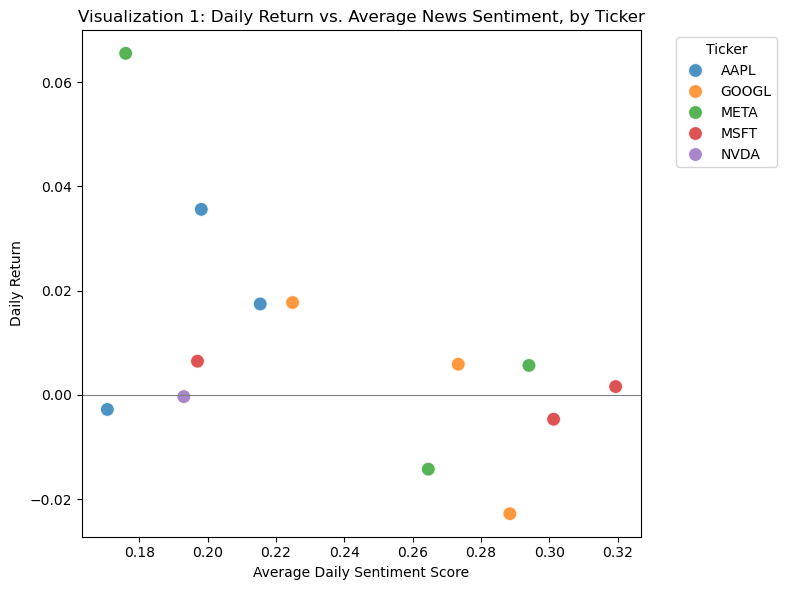

In [77]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=merged_df,
    x="avg_sentiment",
    y="daily_return",
    hue="ticker",
    s=100,
    alpha=0.8,
)
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Visualization 1: Daily Return vs. Average News Sentiment, by Ticker")
plt.xlabel("Average Daily Sentiment Score")
plt.ylabel("Daily Return")
plt.legend(title="Ticker", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

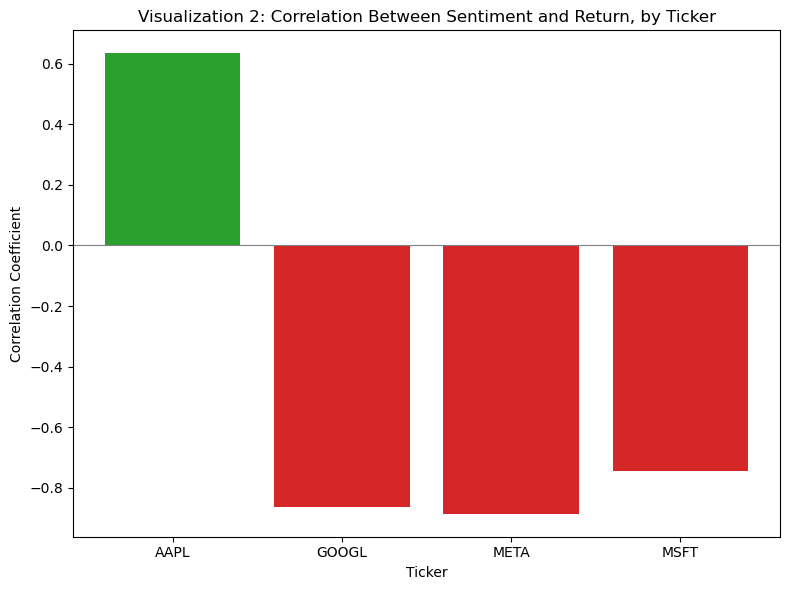

In [79]:
ticker_corr = merged_df.groupby("ticker")[["daily_return", "avg_sentiment"]].apply(
    lambda g: g["daily_return"].corr(g["avg_sentiment"]) if len(g) > 1 else None
).reset_index(name="correlation")

plt.figure(figsize=(8, 6))
colors = ["tab:green" if c > 0 else "tab:red" for c in ticker_corr["correlation"].fillna(0)]
plt.bar(ticker_corr["ticker"], ticker_corr["correlation"], color=colors)
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Visualization 2: Correlation Between Sentiment and Return, by Ticker")
plt.xlabel("Ticker")
plt.ylabel("Correlation Coefficient")
plt.tight_layout()
plt.show()